In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append("../../src/")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

import scipy.stats as stats
from tqdm import tqdm
from network import FeedForward
from helper_functions import circular_gaussian

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [4]:
seed = 1

network = FeedForward(init_steps=300, seed=seed)

# Baseline
POs = network.get_POs_over_trials(network.w_ef_baseline, network.n_steps, 'baseline')
drift_mag_baseline, drift_rate_baseline, convergence_baseline = network.get_metrics(network.N, network.n_days, network.theta_stim, network.POs)

# with inhibition
network_inh = FeedForward(inh="on", inh_type="co-tuned", inh_scale=0.8, seed=seed)
POs = network_inh.get_POs_over_trials(network_inh.w_ef_baseline, network_inh.n_steps, 'baseline')
drift_mag_inh, drift_rate_inh, convergence_inh = network_inh.get_metrics(network_inh.N, network_inh.n_days, network_inh.theta_stim, network_inh.POs)

setting seed: 1


100%|██████████| 840/840 [00:11<00:00, 72.65it/s]


setting seed: 1


100%|██████████| 840/840 [00:10<00:00, 78.01it/s]


### Plot weights

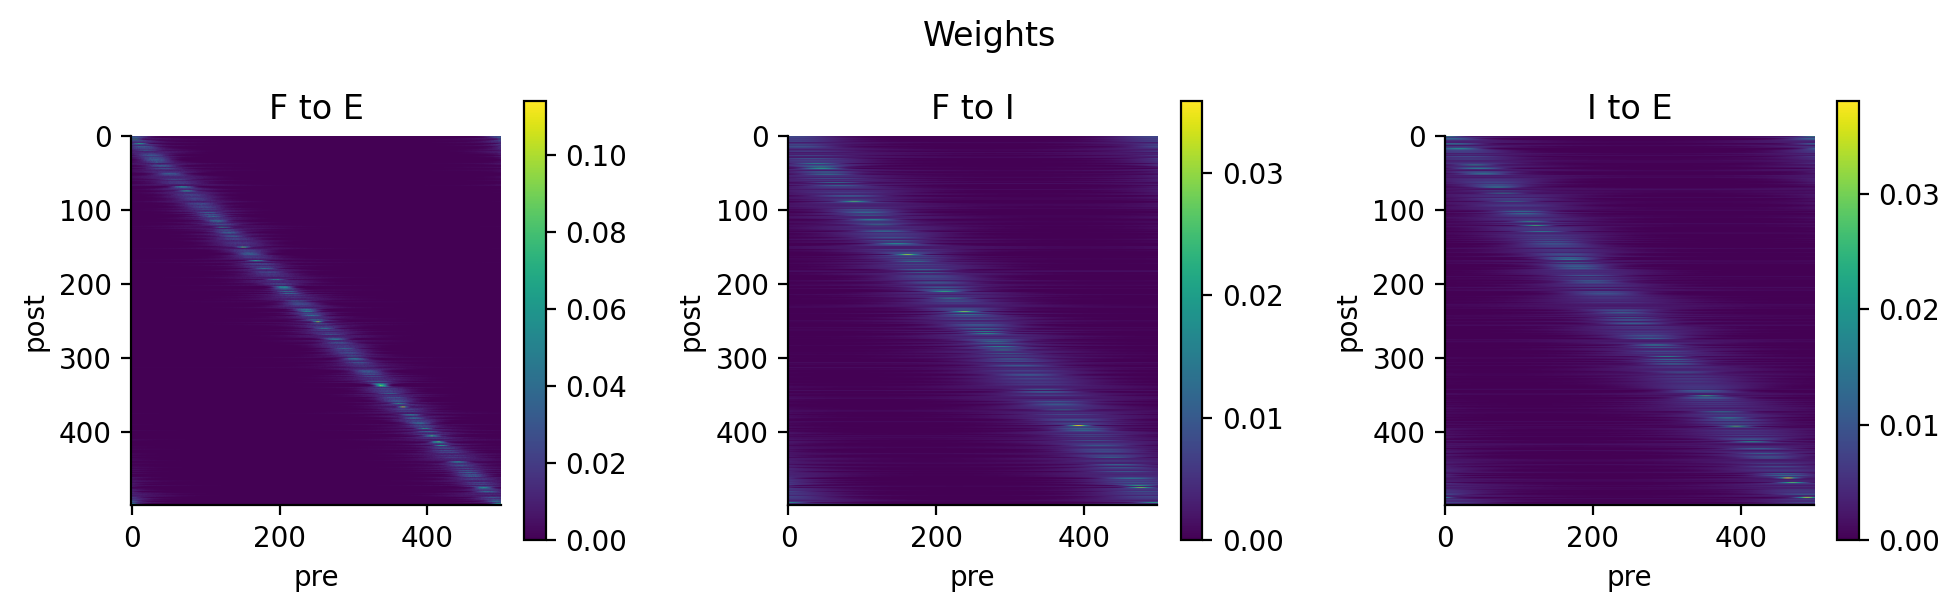

In [6]:
# vmin = 0
# vmax = 0.05

fig, axs = plt.subplots(1, 3, figsize=(10, 3), dpi=200)

# im1 = axs[0].imshow(network_inh.w_ef_init.T, vmin=vmin, vmax=vmax)
im1 = axs[0].imshow(network_inh.w_ef_init.T)
fig.colorbar(im1, ax=axs[0])
axs[0].set_xlabel("pre")
axs[0].set_ylabel("post")
axs[0].set_title("F to E")

im2 = axs[1].imshow(network_inh.w_if.T)
fig.colorbar(im2, ax=axs[1])
axs[1].set_xlabel("pre")
axs[1].set_ylabel("post")
axs[1].set_title("F to I")

im3 = axs[2].imshow(network_inh.w_ei.T)
fig.colorbar(im3, ax=axs[2])
axs[2].set_xlabel("pre")
axs[2].set_ylabel("post")
axs[2].set_title("I to E")

fig.suptitle("Weights")
fig.tight_layout()

fig.savefig("../../results/co-tuned_inhibition/weights.svg")

### Drift rate

<>:38: SyntaxWarning: invalid escape sequence '\;'
<>:38: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_24408/4116655140.py:38: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_24408/4116655140.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


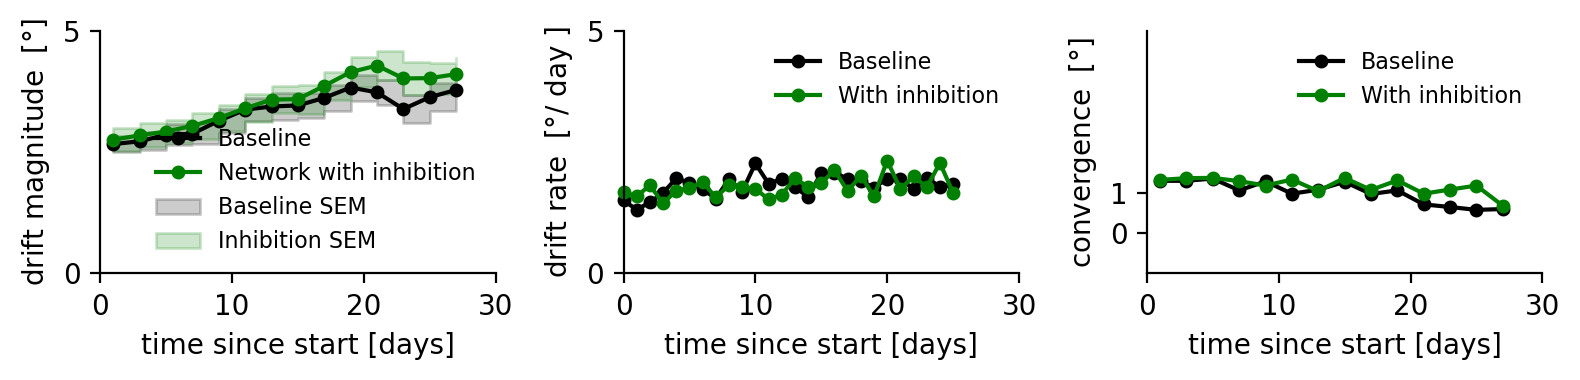

In [8]:
eo = 2

fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=200)
axs[0].plot(np.arange(1, network.n_days)[::eo], np.median(drift_mag_baseline, axis=1)[:-1][::eo], c='black', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[0].plot(np.arange(1, network.n_days)[::eo], np.median(drift_mag_inh, axis=1)[:-1][::eo], c='green', ls='-', marker='o', ms=4, label='Network with inhibition', clip_on=False)

# plot shaded error bars for baseline
baseline_mean = np.mean(drift_mag_baseline, axis=1)[:-1]
baseline_median = np.median(drift_mag_baseline, axis=1)[:-1]
baseline_sem = stats.sem(drift_mag_baseline, axis=1)[:-1]
axs[0].fill_between(np.arange(1, network.n_days)[::eo], baseline_median[::eo] - baseline_sem[::eo], baseline_median[::eo] + baseline_sem[::eo], color='black', alpha=0.2, step='post', label='Baseline SEM')

# plot shaded error bars for inhibition
inh_mean = np.mean(drift_mag_inh, axis=1)[:-1]
inh_median = np.median(drift_mag_inh, axis=1)[:-1]
inh_sem = stats.sem(drift_mag_inh, axis=1)[:-1]
axs[0].fill_between(np.arange(1, network.n_days)[::eo], inh_median[::eo] - inh_sem[::eo], inh_median[::eo] + inh_sem[::eo], color='green', alpha=0.2, step='post', label='Inhibition SEM')

axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate_baseline, axis=1)[:-1], c='black', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[1].plot(np.mean(drift_rate_inh, axis=1)[:-1], c='green', ls='-', marker='o', ms=4, label='With inhibition', clip_on=False)
axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, network_inh.n_days)[::eo], np.median(convergence_baseline, axis=1)[::eo], c='black', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[2].plot(np.arange(1, network_inh.n_days)[::eo], np.median(convergence_inh, axis=1)[::eo], c='green', ls='-', marker='o', ms=4, label='With inhibition', clip_on=False)
axs[2].set_ylim([-1, 5]); axs[2].set_yticks([0, 1])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

# fig.savefig("../../results/co-tuned_inhibition/drift_co-tuned_inhibition - baseline vs inh.svg")
fig.tight_layout()
fig.show()

### Tuning curve dynamics

In [8]:
num_stimuli = 500
N = 500
theta_list = np.linspace(0, 180, 500)

tuning_curves_initial = np.empty((N, num_stimuli))
tuning_curves_final = np.empty((N, num_stimuli))

for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh.w_if.T.dot(u)
    e_initial = network_inh.w_ef_init.T.dot(u) - network_inh.w_ei.T.dot(i)
    e_initial[e_initial < 0] = 0
    tuning_curves_initial[:, stim_num] = e_initial
    
for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh.w_if.T.dot(u)
    e_final = network_inh.W[:, :, -1].T.dot(u) - network_inh.w_ei.T.dot(i)
    e_final[e_final < 0] = 0
    tuning_curves_final[:, stim_num] = e_final

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_21870/3830280076.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


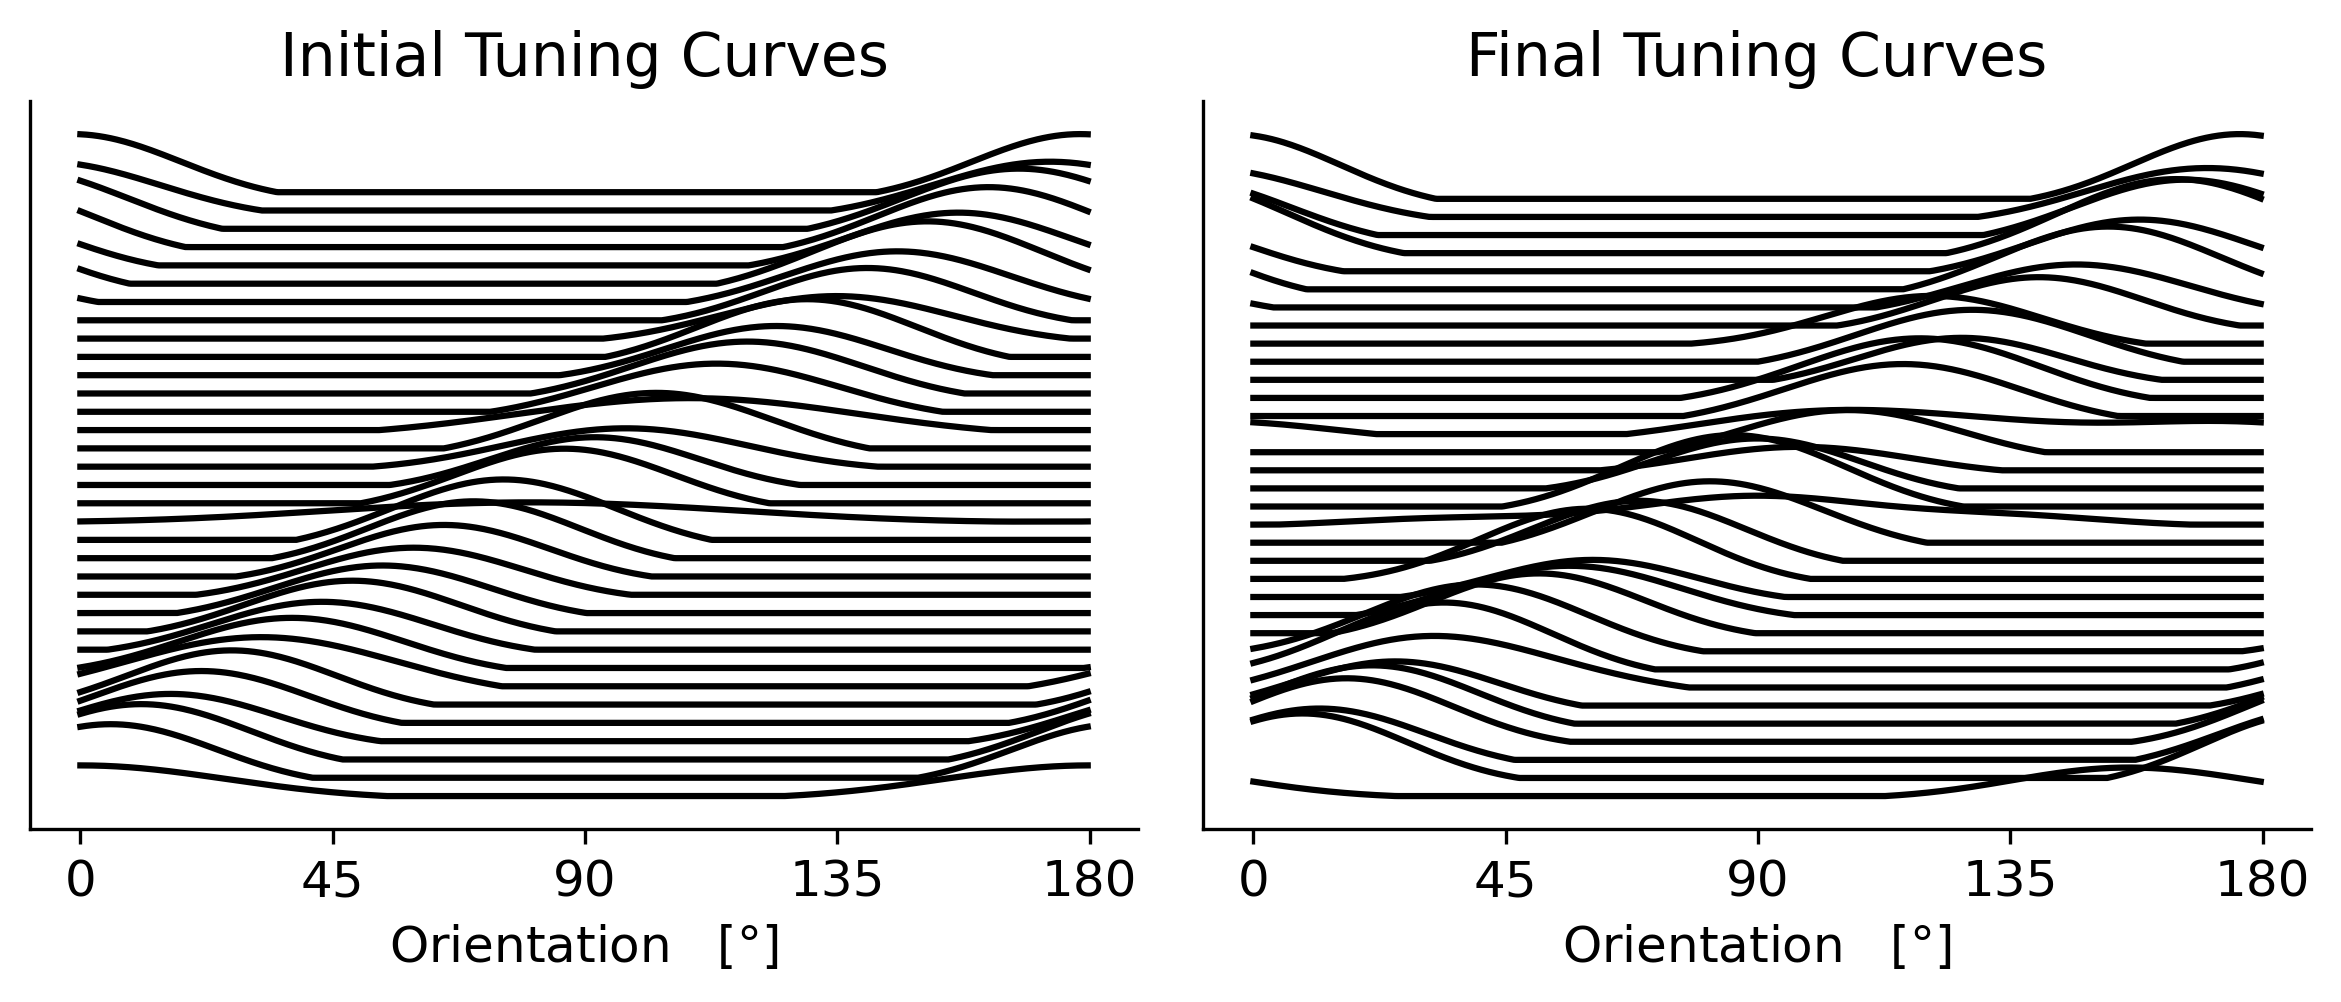

In [9]:

plt.rcParams['font.size'] = 12
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), dpi=300)

for i in range(0, N, 15):
    axs[0].plot(tuning_curves_initial[i] + 0.028*i, color='black')

    axs[0].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
    axs[0].set_xticklabels([0, 45, 90, 135, 180])
    axs[0].set_xlabel(r'Orientation  $ \; [\degree]$')

for i in range(0, N, 15):
    axs[1].plot(tuning_curves_final[i] + 0.028*i, color='black')

    axs[1].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
    axs[1].set_xticklabels([0, 45, 90, 135, 180])
    axs[1].set_xlabel(r'Orientation  $ \; [\degree]$')

axs[0].set_yticks([], [])
axs[1].set_yticks([], [])

axs[0].title.set_text("Initial Tuning Curves")
axs[1].title.set_text("Final Tuning Curves")

fig.tight_layout()
fig.savefig("../../results/co-tuned_inhibition/tuning_curves_co-tuned_inhibition.svg")
fig.show()

In [10]:
### Evaluate tuning curves over time
num_stimuli = 500
N = 500
theta_list = np.linspace(0, 180, 500)

tuning_curves_over_time = np.empty((N, num_stimuli, network.n_steps))

for t in tqdm(range(network.n_steps)):
    for stim_num, theta in enumerate(theta_list):
        u = circular_gaussian(N, theta)
        i = network_inh.w_if.T.dot(u)
        e = network_inh.W[:, :, t].T.dot(u) - network_inh.w_ei.T.dot(i)
        e[e < 0] = 0
        tuning_curves_over_time[:, stim_num, t] = e

100%|██████████| 840/840 [06:12<00:00,  2.26it/s]


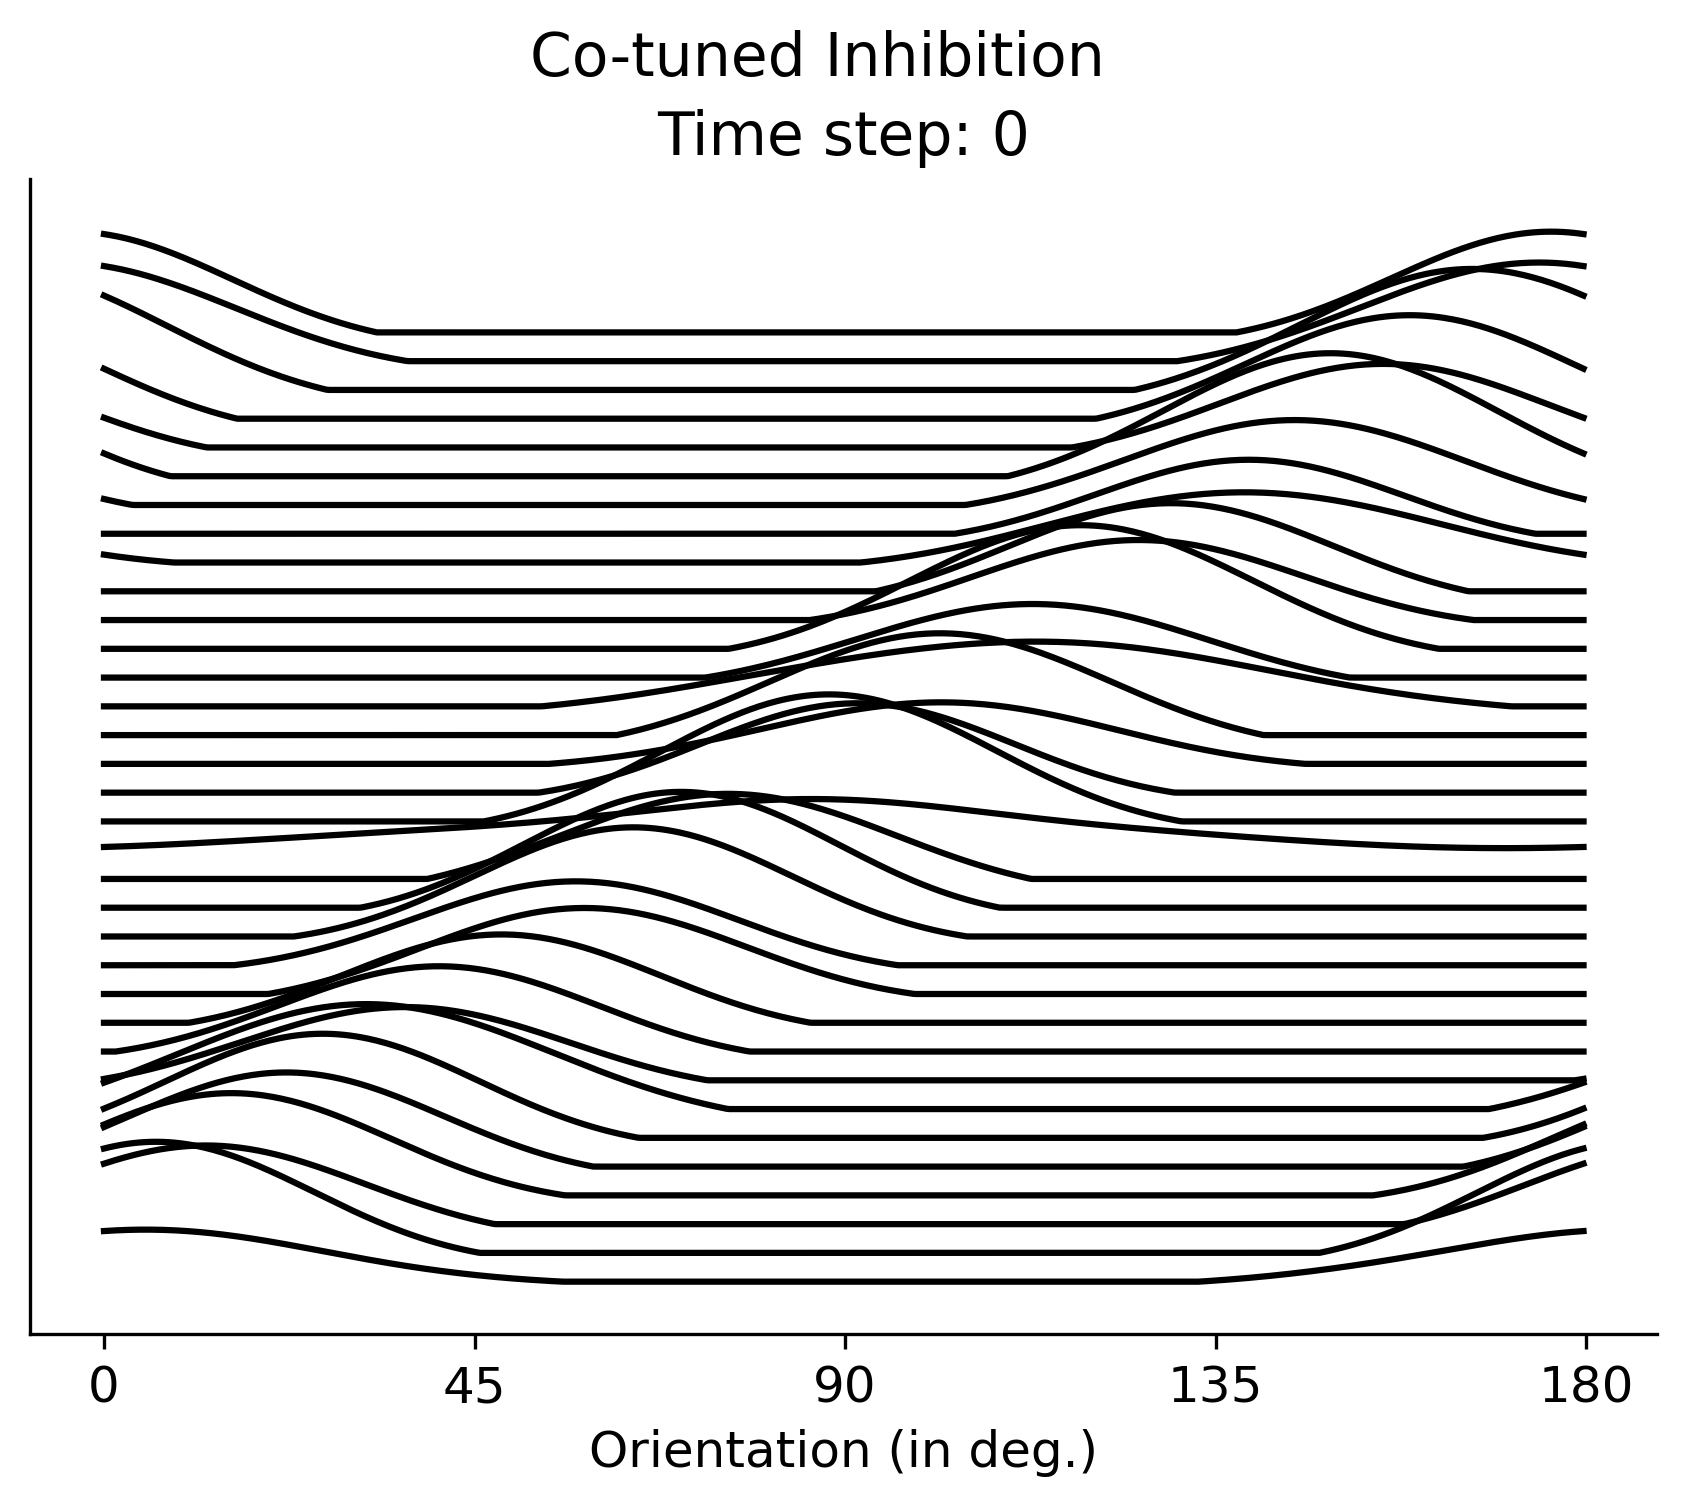

MovieWriter imagemagick unavailable; using Pillow instead.


In [11]:

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

lines = []
for i in range(0, N, 15):
    line, = ax.plot(tuning_curves_over_time[i, :, 0] + 0.028*i, color='black')
    lines.append(line)

ax.set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
ax.set_xticklabels([0, 45, 90, 135, 180])
ax.set_xlabel("Orientation (in deg.)")
ax.set_yticks([], [])
fig.suptitle("Co-tuned Inhibition")
def update(frame):
    for i, line in enumerate(lines):
        line.set_ydata(tuning_curves_over_time[i*15, :, frame] + 0.028*i*15)
    ax.set_title(f'Time step: {frame}')
    return lines

ani = FuncAnimation(fig, update, frames=tuning_curves_over_time.shape[2], blit=True)

plt.show()
ani.save("../../results/co-tuned_inhibition/excitatory_tuning_over_time.gif", writer='imagemagick', fps=10)

### Show tuning width reduction over three different levels of inhibition

In [12]:
inh_1_scale = 0.3
inh_2_scale = 0.7
inh_3_scale = 1.1

seed = 1

network_inh_1 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_1_scale, seed=seed)
POs_1 = network_inh_1.get_POs_over_trials(network_inh_1.w_ef_baseline, network_inh_1.n_steps, 'baseline')
drift_mag_inh_1, drift_rate_inh_1, convergence_inh_1 = network_inh_1.get_metrics(network_inh_1.N, network_inh_1.n_days, network_inh_1.theta_stim, network_inh_1.POs)

network_inh_2 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_2_scale, seed=seed)
POs_2 = network_inh_2.get_POs_over_trials(network_inh_2.w_ef_baseline, network_inh_2.n_steps, 'baseline')
drift_mag_inh_2, drift_rate_inh_2, convergence_inh_2 = network_inh_2.get_metrics(network_inh_2.N, network_inh_2.n_days, network_inh_2.theta_stim, network_inh_2.POs)

network_inh_3 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_3_scale, seed=seed)
POs_3 = network_inh_3.get_POs_over_trials(network_inh_3.w_ef_baseline, network_inh_3.n_steps, 'baseline')
drift_mag_inh_3, drift_rate_inh_3, convergence_inh_3 = network_inh_3.get_metrics(network_inh_3.N, network_inh_3.n_days, network_inh_3.theta_stim, network_inh_3.POs)


setting seed: 1


100%|██████████| 840/840 [00:11<00:00, 74.28it/s]


setting seed: 1


100%|██████████| 840/840 [00:09<00:00, 85.62it/s]


setting seed: 1


100%|██████████| 840/840 [00:09<00:00, 87.84it/s]


<>:30: SyntaxWarning: invalid escape sequence '\;'
<>:30: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_21870/485109591.py:30: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_21870/485109591.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


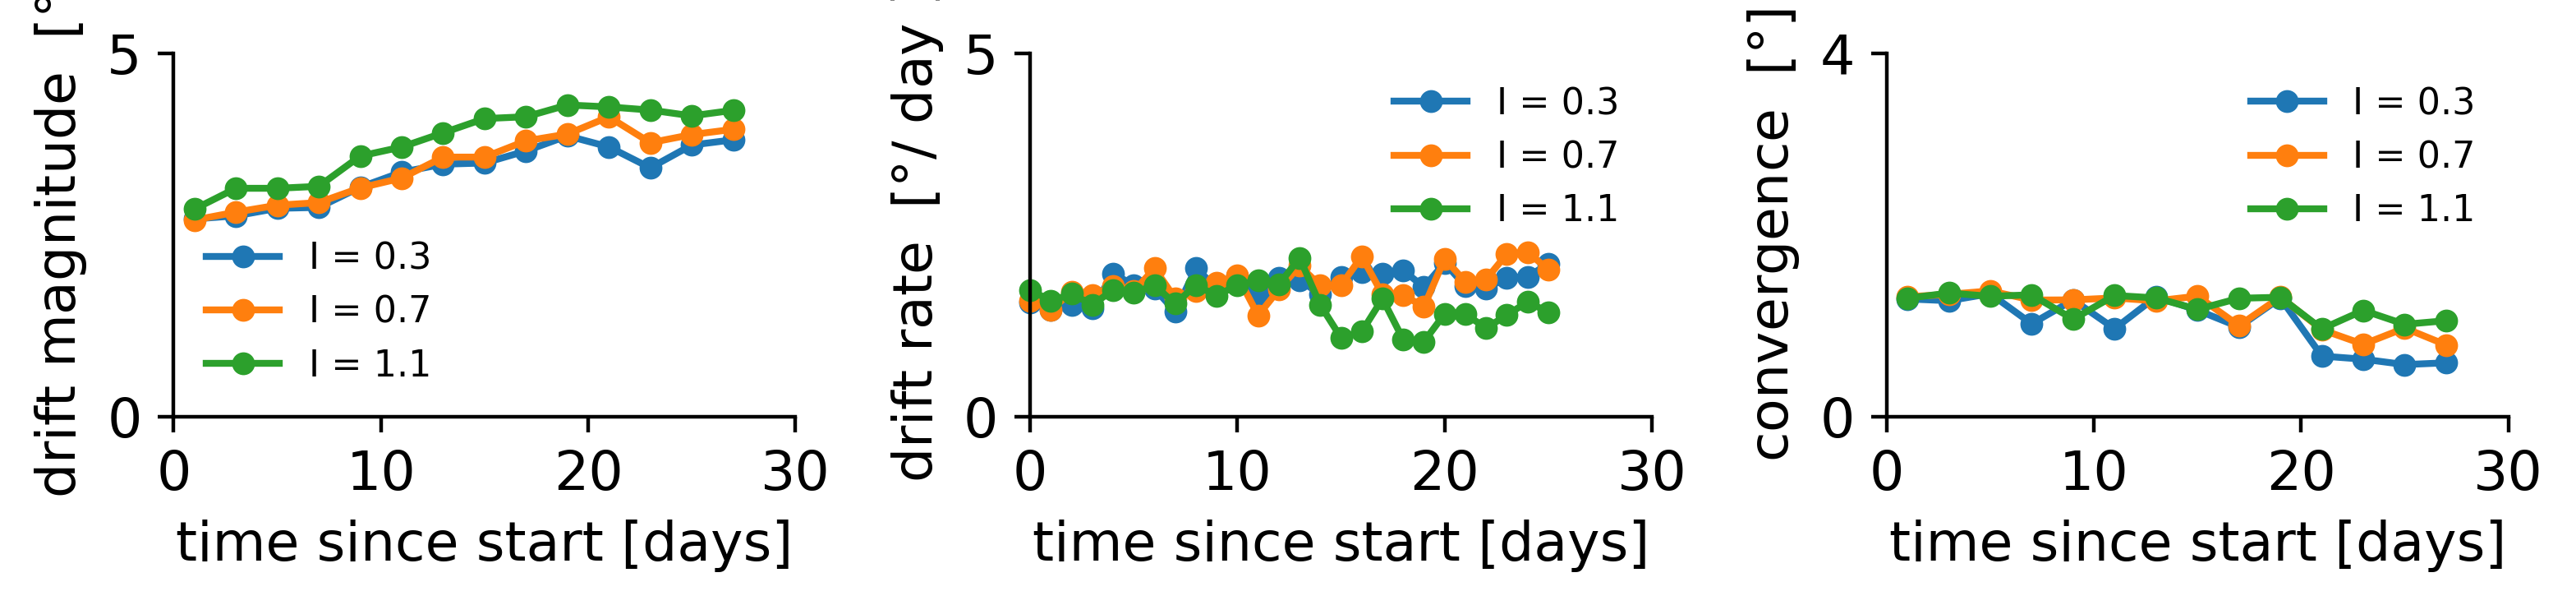

In [13]:
eo = 2

fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=400)
axs[0].plot(np.arange(1, network_inh_1.n_days)[::eo], np.median(drift_mag_inh_1, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[0].plot(np.arange(1, network_inh_2.n_days)[::eo], np.median(drift_mag_inh_2, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[0].plot(np.arange(1, network_inh_3.n_days)[::eo], np.median(drift_mag_inh_3, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)

axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate_inh_1, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[1].plot(np.mean(drift_rate_inh_2, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[1].plot(np.mean(drift_rate_inh_3, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)

axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, network_inh_1.n_days)[::eo], np.median(convergence_inh_1, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[2].plot(np.arange(1, network_inh_2.n_days)[::eo], np.median(convergence_inh_2, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[2].plot(np.arange(1, network_inh_3.n_days)[::eo], np.median(convergence_inh_3, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)
axs[2].set_ylim([0, 4]); axs[2].set_yticks([0, 4])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

# fig.savefig("../../results/co-tuned_inhibition/drift_co-tuned_inhibition_3_levels.svg")

In [14]:
num_stimuli = 500
N = 500
theta_list = np.linspace(0, 180, 500)

tuning_curves_initial_1 = np.empty((N, num_stimuli))
tuning_curves_final_1 = np.empty((N, num_stimuli))

tuning_curves_initial_2 = np.empty((N, num_stimuli))
tuning_curves_final_2 = np.empty((N, num_stimuli))

tuning_curves_initial_3 = np.empty((N, num_stimuli))
tuning_curves_final_3 = np.empty((N, num_stimuli))


for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_1.w_if.T.dot(u)
    e_initial = network_inh_1.w_ef_init.T.dot(u) - network_inh_1.w_ei.T.dot(i)
    e_initial[e_initial < 0] = 0
    tuning_curves_initial_1[:, stim_num] = e_initial
    
for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_1.w_if.T.dot(u)
    e_final = network_inh_1.W[:, :, -1].T.dot(u) - network_inh_1.w_ei.T.dot(i)
    e_final[e_final < 0] = 0
    tuning_curves_final_1[:, stim_num] = e_final

### network 2

for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_2.w_if.T.dot(u)
    e_initial = network_inh_2.w_ef_init.T.dot(u) - network_inh_2.w_ei.T.dot(i)
    e_initial[e_initial < 0] = 0
    tuning_curves_initial_2[:, stim_num] = e_initial
    
for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_2.w_if.T.dot(u)
    e_final = network_inh_2.W[:, :, -1].T.dot(u) - network_inh_2.w_ei.T.dot(i)
    e_final[e_final < 0] = 0
    tuning_curves_final_2[:, stim_num] = e_final

### network 3

for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_3.w_if.T.dot(u)
    e_initial = network_inh_3.w_ef_init.T.dot(u) - network_inh_3.w_ei.T.dot(i)
    e_initial[e_initial < 0] = 0
    tuning_curves_initial_3[:, stim_num] = e_initial
    
for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_3.w_if.T.dot(u)
    e_final = network_inh_3.W[:, :, -1].T.dot(u) - network_inh_3.w_ei.T.dot(i)
    e_final[e_final < 0] = 0
    tuning_curves_final_3[:, stim_num] = e_final


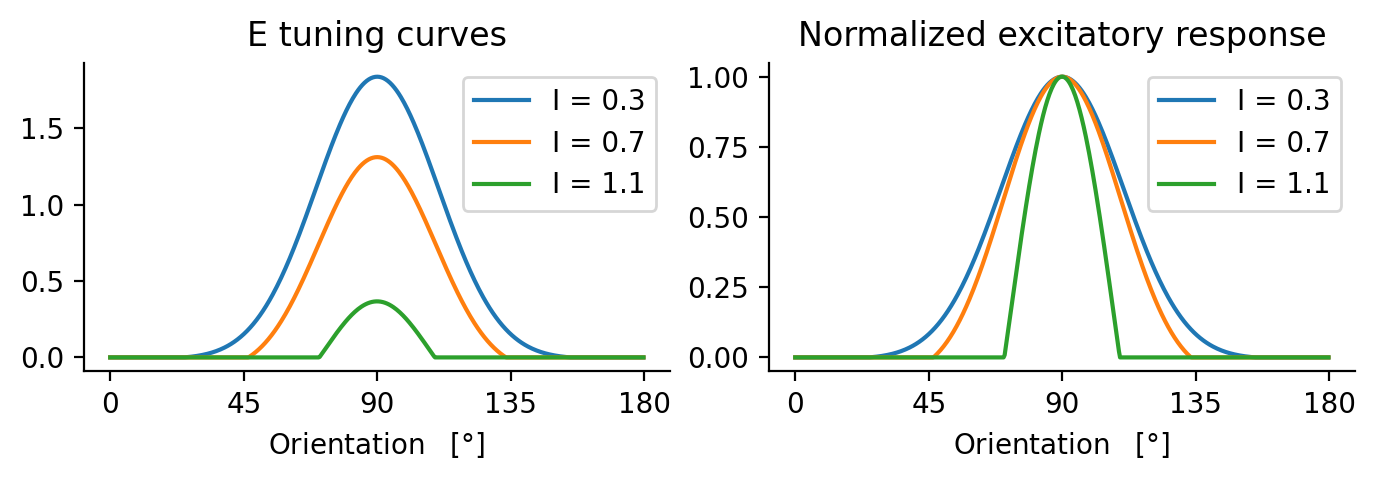

In [15]:
plt.rcParams['font.size'] = 10
fig, axs = plt.subplots(1, 2, figsize=(7, 2.5), dpi=200)
i = 250

axs[0].plot(tuning_curves_initial_1[i], label=f'I = {inh_1_scale}')
axs[0].plot(tuning_curves_initial_2[i], label=f'I = {inh_2_scale}')
axs[0].plot(tuning_curves_initial_3[i], label=f'I = {inh_3_scale}')

axs[0].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
axs[0].set_xticklabels([0, 45, 90, 135, 180])
axs[0].set_xlabel(r'Orientation  $ \; [\degree]$')

axs[0].set_title("E tuning curves")
axs[0].legend()

axs[1].plot(tuning_curves_initial_1[i]/np.max(tuning_curves_initial_1[i]), label=f'I = {inh_1_scale}')
axs[1].plot(tuning_curves_initial_2[i]/np.max(tuning_curves_initial_2[i]), label=f'I = {inh_2_scale}')
axs[1].plot(tuning_curves_initial_3[i]/np.max(tuning_curves_initial_3[i]), label=f'I = {inh_3_scale}')

axs[1].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
axs[1].set_xticklabels([0, 45, 90, 135, 180])
axs[1].set_xlabel(r'Orientation  $ \; [\degree]$')

axs[1].set_title("Normalized excitatory response")
axs[1].legend()

fig.tight_layout()
fig.savefig("../../results/co-tuned_inhibition/E_tuning_curve_across_I_scales.svg")

In [ ]:
### Evaluate tuning curves over time
num_stimuli = 500
N = 500
theta_list = np.linspace(0, 180, 500)

tuning_curves_over_time_1 = np.empty((N, num_stimuli, network.n_steps))
tuning_curves_over_time_2 = np.empty((N, num_stimuli, network.n_steps))
tuning_curves_over_time_3 = np.empty((N, num_stimuli, network.n_steps))


for t in tqdm(range(network.n_steps)):
    for stim_num, theta in enumerate(theta_list):
        u = circular_gaussian(N, theta)
        i = network_inh_1.w_if.T.dot(u)
        e = network_inh_1.W[:, :, t].T.dot(u) - network_inh_1.w_ei.T.dot(i)
        e[e < 0] = 0
        tuning_curves_over_time_1[:, stim_num, t] = e

for t in tqdm(range(network.n_steps)):
    for stim_num, theta in enumerate(theta_list):
        u = circular_gaussian(N, theta)
        i = network_inh_2.w_if.T.dot(u)
        e = network_inh_2.W[:, :, t].T.dot(u) - network_inh_2.w_ei.T.dot(i)
        e[e < 0] = 0
        tuning_curves_over_time_2[:, stim_num, t] = e

for t in tqdm(range(network.n_steps)):
    for stim_num, theta in enumerate(theta_list):
        u = circular_gaussian(N, theta)
        i = network_inh_3.w_if.T.dot(u)
        e = network_inh_3.W[:, :, t].T.dot(u) - network_inh_3.w_ei.T.dot(i)
        e[e < 0] = 0
        tuning_curves_over_time_3[:, stim_num, t] = e

 85%|████████▌ | 718/840 [05:39<01:00,  2.01it/s]

So it seems that adding a small amount of inhibition (such that the excitatory activity looks reasonable) has no effect on drift.

The question now would be, when does this fail?
 - do a systematic increase in inhibition, until the drift magnitude & rate plots change behavior, and see how this increase in inhibition affects excitatory population firing and how it affects the tuning curves

### Population activity of excitatory and inhibitory neurons

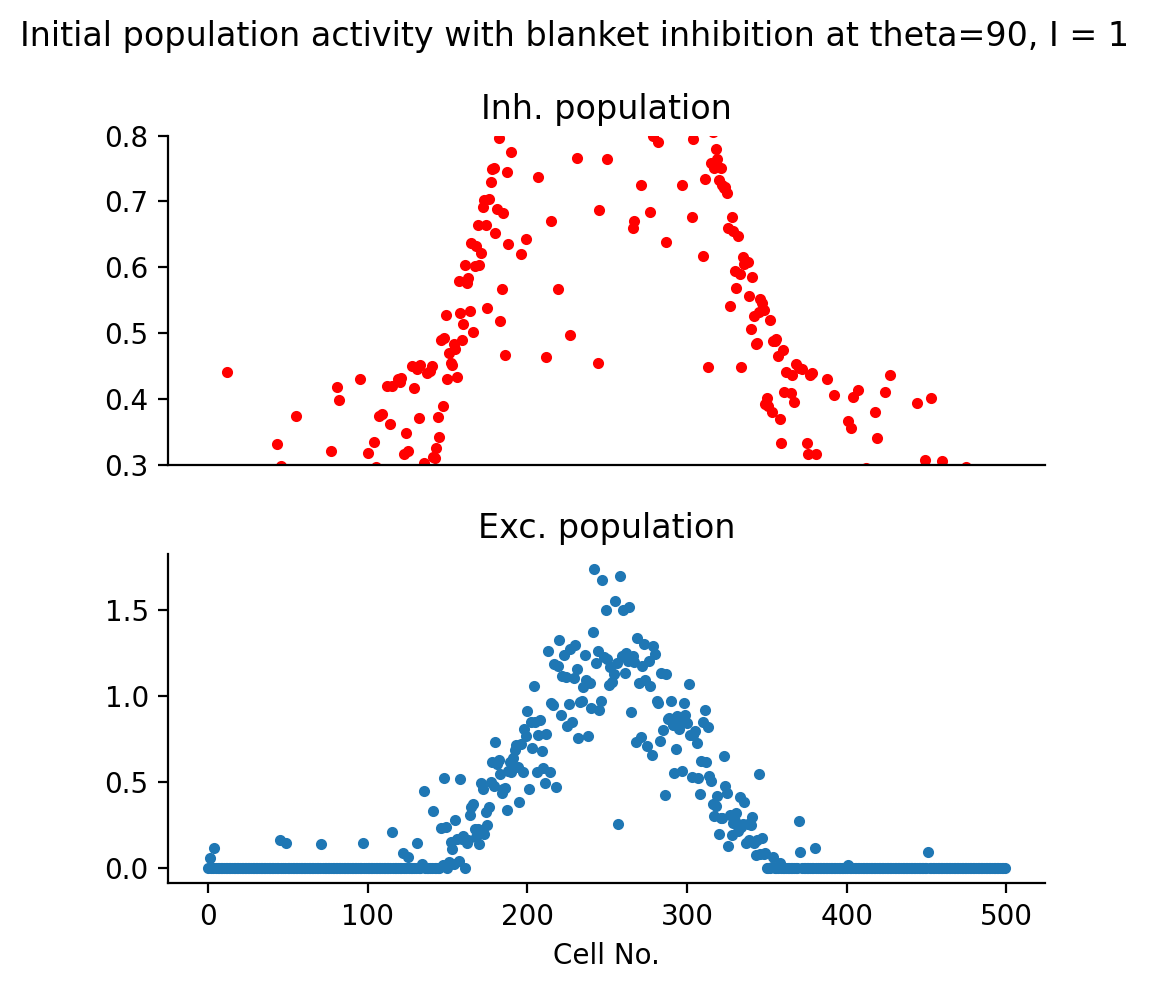

In [ ]:
theta = 90
u = circular_gaussian(500, theta)
i = network_inh.w_if.T.dot(u)
e = network_inh.W[:, :, 100].T.dot(u) - network_inh.w_ei.T.dot(i)
e[e < 0] = 0

fig, axs = plt.subplots(2, 1, figsize=(5, 5), dpi=200)
axs[0].plot(i, '.', color="r")
axs[0].set_ylim((0.3, 0.8))
axs[0].set_xticks([], [])
axs[0].set_title("Inh. population")

axs[1].plot(e, '.')
axs[1].set_title("Exc. population")

axs[1].set_xlabel("Cell No.")
fig.suptitle("Initial population activity with blanket inhibition at theta=90, I = 1")
fig.tight_layout()

MovieWriter ffmpeg unavailable; using Pillow instead.


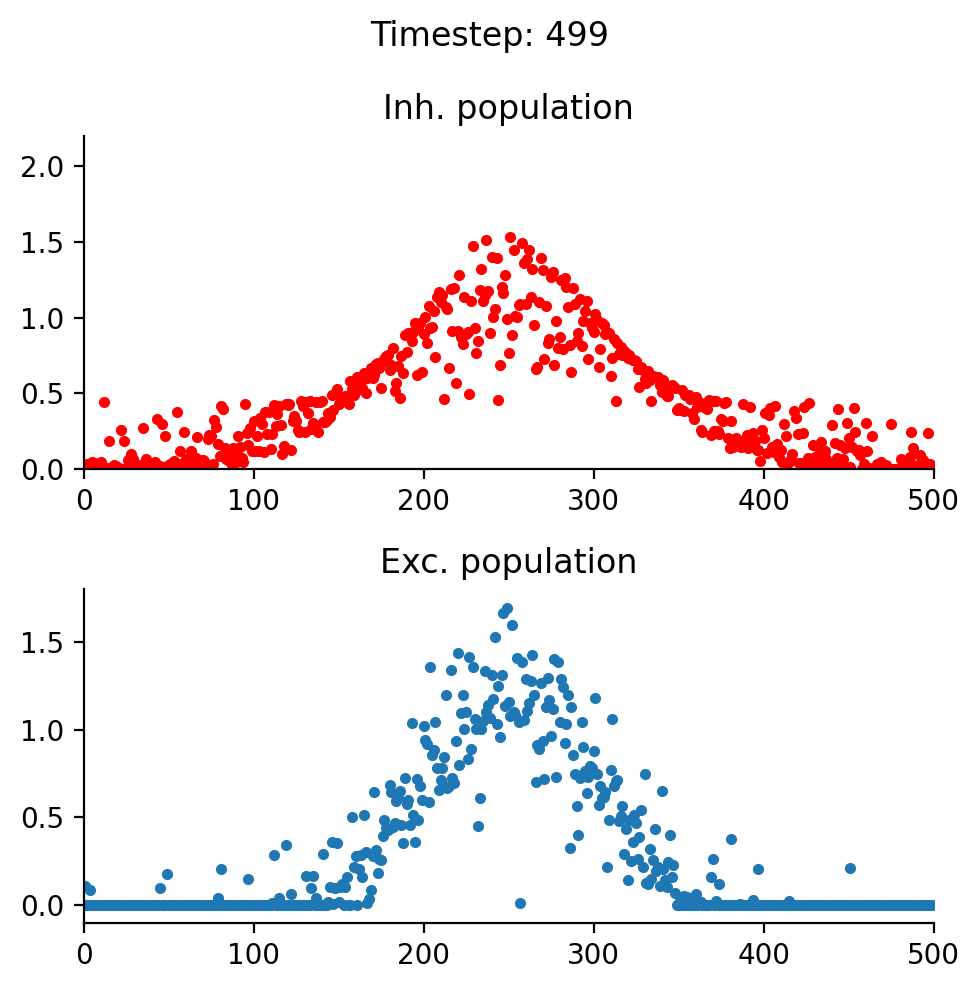

In [ ]:
# Initialize the figure and axes

time_steps = len(network_inh.W[:, :])
theta = 90
u = circular_gaussian(500, theta)

fig, axs = plt.subplots(2, 1, figsize=(5, 5), dpi=200)
inh_line, = axs[0].plot([], '.', color="r")
exc_line, = axs[1].plot([], '.')

axs[0].set_ylim((0, 2.2))
axs[0].set_xlim((0, 500))
axs[1].set_xlim((0, 500))
axs[1].set_ylim((-0.1, 1.8))
axs[0].set_title("Inh. population")
axs[1].set_title("Exc. population")
fig.suptitle("Population activity over time with blanket inhibition")
fig.tight_layout()

# Update function for the animation
def update(frame):
    i = network_inh.w_if.T.dot(u)
    e = network_inh.W[:, :, frame].T.dot(u) - network_inh.w_ei.T.dot(i)
    e[e < 0] = 0

    inh_line.set_data(range(len(i)), i)
    exc_line.set_data(range(len(e)), e)

    fig.suptitle(f"Timestep: {frame}")
    return inh_line, exc_line

# Set up the animation
ani = FuncAnimation(fig, update, frames=time_steps, blit=True)

ani.save("../../results/co-tuned_inhibition/population_activit_at_90_animation.gif", writer='ffmpeg')

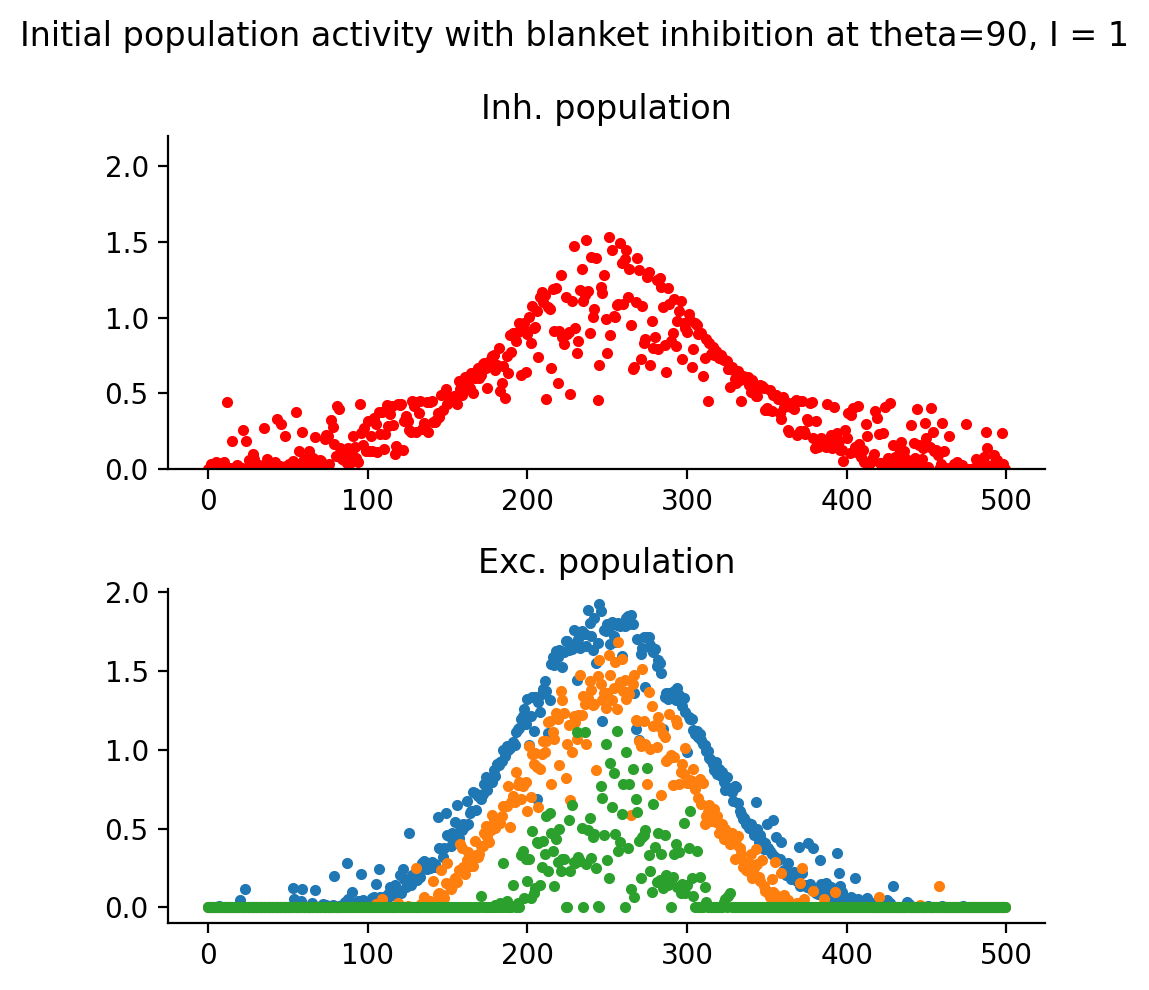

In [ ]:
### across three scales of inhibition

theta = 90
u = circular_gaussian(500, theta)

i_1 = network_inh_1.w_if.T.dot(u)
e_1 = network_inh_1.w_ef_init.T.dot(u) - network_inh_1.w_ei.T.dot(i_1)
e_1[e_1 < 0] = 0

i_2 = network_inh_2.w_if.T.dot(u)
e_2 = network_inh_2.w_ef_init.T.dot(u) - network_inh_2.w_ei.T.dot(i_2)
e_2[e_2 < 0] = 0

i_3 = network_inh_3.w_if.T.dot(u)
e_3 = network_inh_3.w_ef_init.T.dot(u) - network_inh_3.w_ei.T.dot(i_3)
e_3[e_3 < 0] = 0


fig, axs = plt.subplots(2, 1, figsize=(5, 5), dpi=200)
axs[0].plot(i, '.', color="r")
axs[0].set_ylim((0, 2.2))
axs[0].set_title("Inh. population")

axs[1].plot(e_1, '.', label=f"I = {inh_1_scale}")
axs[1].plot(e_2, '.', label=f"I = {inh_2_scale}")
axs[1].plot(e_3, '.', label=f"I = {inh_3_scale}")

axs[1].set_title("Exc. population")

fig.suptitle("Initial population activity with blanket inhibition at theta=90, I = 1")
fig.tight_layout()


### Preferred Orientation dynamics across inhibition levels

MovieWriter ffmpeg unavailable; using Pillow instead.


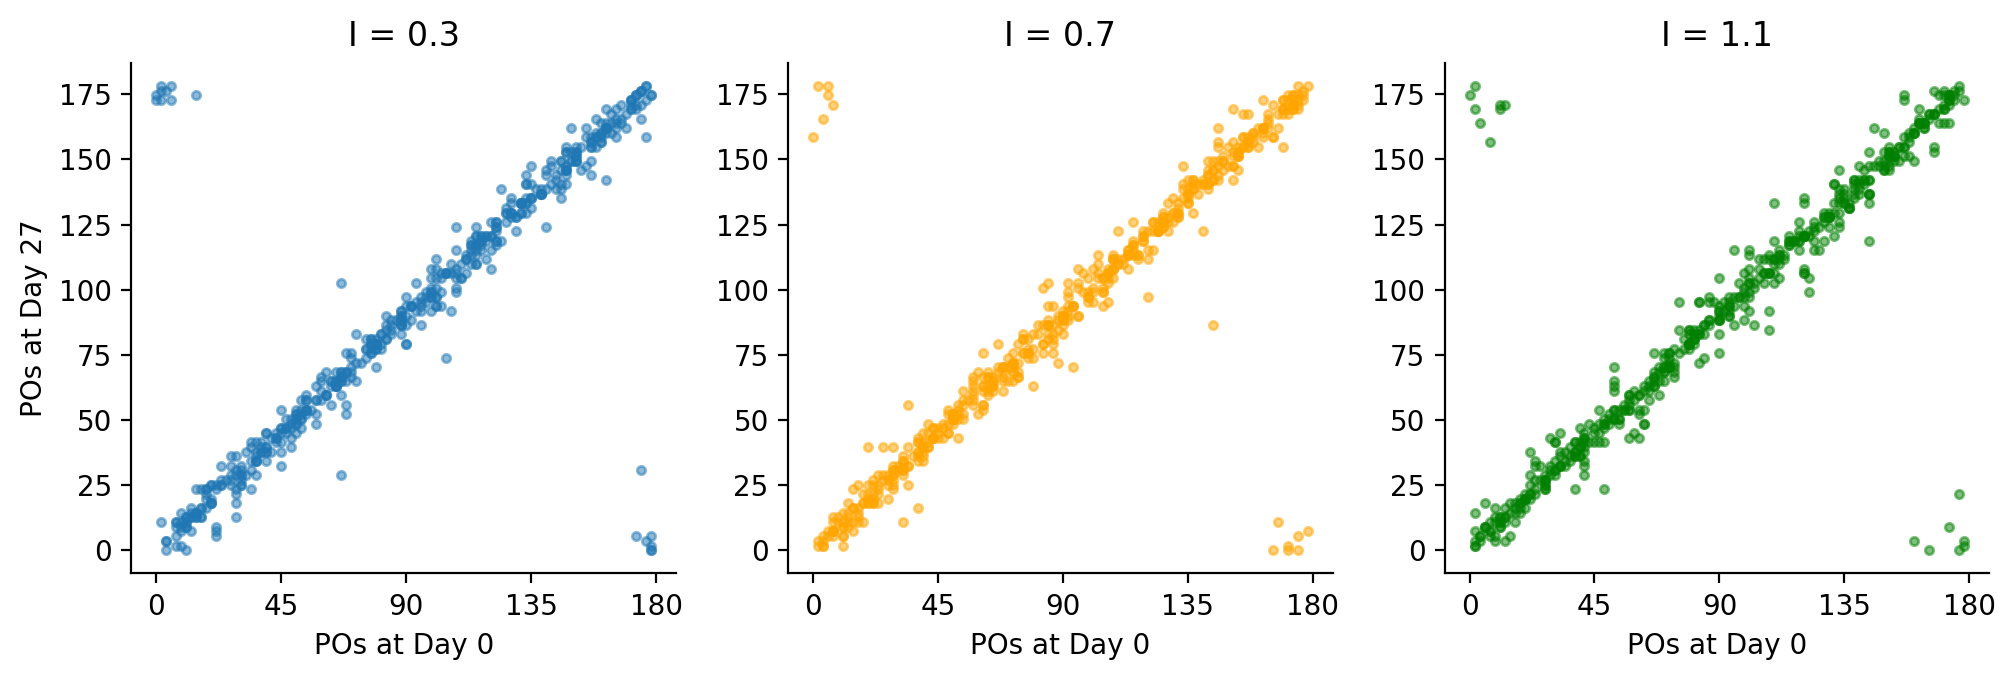

In [ ]:
### Plot initial vs current preferred orientation

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200)

alpha=0.5
 
POs_change_1_line, = axs[0].plot(POs_1[0], POs_1[1], '.', alpha=alpha)


POs_change_2_line, = axs[1].plot(POs_2[0], POs_2[1], '.', color="orange", alpha=alpha)

POs_change_3_line, = axs[2].plot(POs_3[0], POs_3[1], '.', color="green", alpha=alpha)

axs[0].set_xticks(np.arange(0, 181, 45), np.linspace(0, 2*np.pi, 5))
axs[0].set_xticklabels([0, 45, 90, 135, 180])

axs[1].set_xticks(np.arange(0, 181, 45), np.linspace(0, 2*np.pi, 5))
axs[1].set_xticklabels([0, 45, 90, 135, 180])

axs[2].set_xticks(np.arange(0, 181, 45), np.linspace(0, 2*np.pi, 5))
axs[2].set_xticklabels([0, 45, 90, 135, 180])

axs[0].set_title(f"I = {inh_1_scale}")
axs[1].set_title(f"I = {inh_2_scale}")
axs[2].set_title(f"I = {inh_3_scale}")

axs[0].set_xlabel("POs at Day 0")
axs[1].set_xlabel("POs at Day 0")
axs[2].set_xlabel("POs at Day 0")

fig.tight_layout()

def update(frame):
    POs_change_1_line.set_data(POs_1[0], POs_1[frame]) 
    POs_change_2_line.set_data(POs_2[0], POs_2[frame])
    POs_change_3_line.set_data(POs_3[0], POs_3[frame])

    axs[0].set_ylabel(f"POs at Day {frame}")

    fig.suptitle("")
    return POs_change_1_line, POs_change_2_line, POs_change_3_line


ani = FuncAnimation(fig, update, frames=np.arange(28), blit=True)

ani.save("../../results/co-tuned_inhibition/POs across scales.gif", writer="ffmpeg")